In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv('/content/cleaned_churn_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [3]:
# CLV = Monthly Charges × Tenure
df['CLV'] = df['MonthlyCharges'] * df['tenure']

print("CLV Sample:")
print(df[['tenure', 'MonthlyCharges', 'CLV']].head())

CLV Sample:
   tenure  MonthlyCharges      CLV
0       1           29.85    29.85
1      34           56.95  1936.30
2       2           53.85   107.70
3      45           42.30  1903.50
4       2           70.70   141.40


In [4]:
# Average Monthly Spend = TotalCharges / Tenure
# Avoid division by zero
df['AvgMonthlySpend'] = df.apply(
    lambda x: x['TotalCharges'] / x['tenure'] if x['tenure'] > 0 else 0, axis=1
)

print("Avg Monthly Spend Sample:")
print(df[['TotalCharges', 'tenure', 'AvgMonthlySpend']].head())

Avg Monthly Spend Sample:
   TotalCharges  tenure  AvgMonthlySpend
0         29.85       1        29.850000
1       1889.50      34        55.573529
2        108.15       2        54.075000
3       1840.75      45        40.905556
4        151.65       2        75.825000


In [5]:
# Count how many services each customer has subscribed to
service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Convert Yes/No to 1/0 for counting
df['ServiceCount'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1
)

print("Service Count Sample:")
print(df[['ServiceCount']].head(10))

Service Count Sample:
   ServiceCount
0             1
1             3
2             3
3             3
4             1
5             5
6             4
7             1
8             6
9             3


In [6]:
# Month-to-month contracts are higher churn risk
contract_map = {
    'Month-to-month': 3,  # High risk
    'One year': 2,         # Medium risk
    'Two year': 1          # Low risk
}

df['ContractRiskScore'] = df['Contract'].map(contract_map)

print("Contract Risk Score:")
print(df[['Contract', 'ContractRiskScore']].value_counts())

Contract Risk Score:
Contract        ContractRiskScore
Month-to-month  3                    3875
Two year        1                    1695
One year        2                    1473
Name: count, dtype: int64


In [7]:
# Electronic check payments have higher churn rate
df['ElectronicCheckFlag'] = df['PaymentMethod'].apply(
    lambda x: 1 if x == 'Electronic check' else 0
)

print("Electronic Check Flag:")
print(df['ElectronicCheckFlag'].value_counts())

Electronic Check Flag:
ElectronicCheckFlag
0    4678
1    2365
Name: count, dtype: int64


In [8]:
# Group customers by tenure
def tenure_group(tenure):
    if tenure <= 12:
        return 'New'        # 0-12 months
    elif tenure <= 24:
        return 'Growing'    # 13-24 months
    elif tenure <= 48:
        return 'Mature'     # 25-48 months
    else:
        return 'Loyal'      # 48+ months

df['TenureGroup'] = df['tenure'].apply(tenure_group)

print("Tenure Group Distribution:")
print(df['TenureGroup'].value_counts())

Tenure Group Distribution:
TenureGroup
Loyal      2239
New        2186
Mature     1594
Growing    1024
Name: count, dtype: int64


In [9]:
# Flag customers spending above average
avg_spend = df['MonthlyCharges'].mean()

df['HighSpendFlag'] = df['MonthlyCharges'].apply(
    lambda x: 1 if x > avg_spend else 0
)

print(f"Average Monthly Charge: {avg_spend:.2f}")
print(df['HighSpendFlag'].value_counts())

Average Monthly Charge: 64.76
HighSpendFlag
1    3923
0    3120
Name: count, dtype: int64


/tmp/ipykernel_2615/2314095304.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='CLV', data=df, palette='Set2', ax=axes[0, 0])
/tmp/ipykernel_2615/2314095304.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['No Churn', 'Churn'])
/tmp/ipykernel_2615/2314095304.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='ServiceCount', data=df, palette='Set1', ax=axes[0, 1])
/tmp/ipykernel_2615/2314095304.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xti

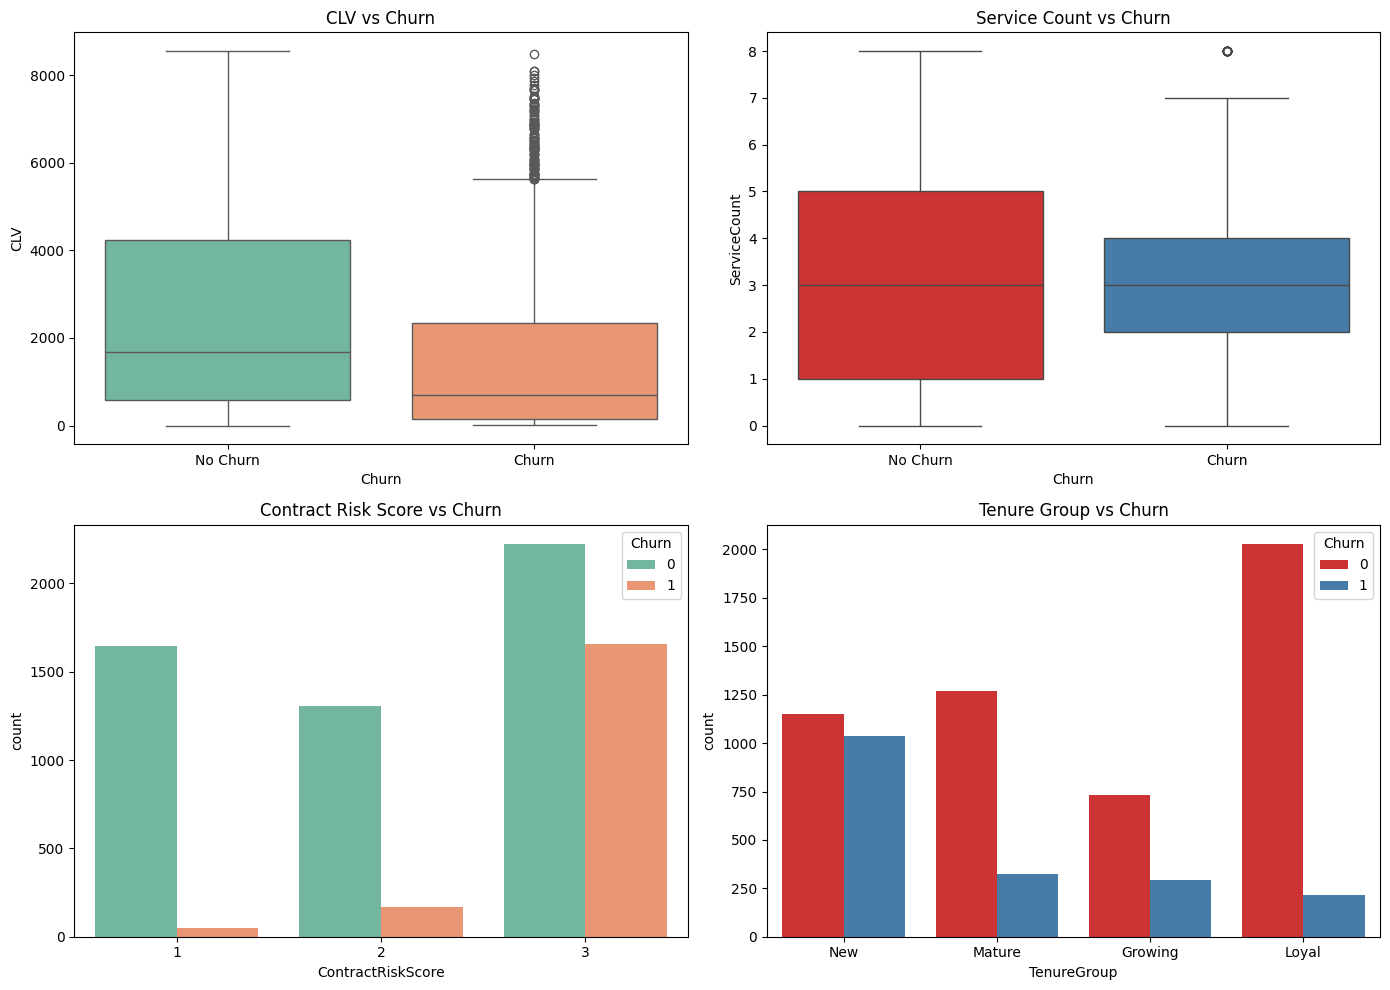

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CLV vs Churn
sns.boxplot(x='Churn', y='CLV', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('CLV vs Churn')
axes[0, 0].set_xticklabels(['No Churn', 'Churn'])

# Service Count vs Churn
sns.boxplot(x='Churn', y='ServiceCount', data=df, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Service Count vs Churn')
axes[0, 1].set_xticklabels(['No Churn', 'Churn'])

# Contract Risk Score vs Churn
sns.countplot(x='ContractRiskScore', hue='Churn', data=df, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Contract Risk Score vs Churn')

# Tenure Group vs Churn
sns.countplot(x='TenureGroup', hue='Churn', data=df, palette='Set1', ax=axes[1, 1])
axes[1, 1].set_title('Tenure Group vs Churn')

plt.tight_layout()
plt.show()

In [11]:
# Save for next notebook
df.to_csv('engineered_churn_data.csv', index=False)
print("✅ Feature engineered dataset saved as 'engineered_churn_data.csv'")
print("New Features Added:")
print(['CLV', 'AvgMonthlySpend', 'ServiceCount',
       'ContractRiskScore', 'ElectronicCheckFlag',
       'TenureGroup', 'HighSpendFlag'])
print("Final Shape:", df.shape)

✅ Feature engineered dataset saved as 'engineered_churn_data.csv'
New Features Added:
['CLV', 'AvgMonthlySpend', 'ServiceCount', 'ContractRiskScore', 'ElectronicCheckFlag', 'TenureGroup', 'HighSpendFlag']
Final Shape: (7043, 27)
